In [26]:
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
from plotly.subplots import make_subplots
import os
from scipy import fftpack
import pandas as pd
from scipy.signal import butter,filtfilt
# Filter requirements.

In [3]:
#Seconds to generate data for
sec = 3
# time range with total samples of 1000 from 0 to 3 with time interval equals 3/1000
time = np.linspace(0, sec, 1000, endpoint=True)
# Generate Signal
signal_freq = 2 # Signal Frequency
signal_amplitude = 10 # Signal Amplitude
#Sine wave Signal
signal = signal_amplitude*np.sin(2*np.pi*signal_freq*time)


In [8]:
# Lets add some noise to the Signal
noise_freq = 50 # Noise Frequency
noise_amplitude = 3 # Noise Amplitude
#Sine wave Noise
noise = noise_amplitude*np.sin(2*np.pi*noise_freq*time) 
# Generated Signal with Noise
signal_noise = signal + noise

In [16]:
sig_noise_fft = fftpack.fft(signal_noise)
sig_noise_amp = 2 / time.size * np.abs(sig_noise_fft)
sig_noise_freq = np.abs(fftpack.fftfreq(time.size, 3/1000))

In [24]:
signal_amplitude = pd.Series(sig_noise_amp).nlargest(2).round(0).astype(int).tolist()
print(signal_amplitude)

[10, 10]


In [31]:
#Calculate Frequency Magnitude
magnitudes = abs(sig_noise_fft[np.where(sig_noise_freq >= 0)])
#Get index of top 2 frequencies
peak_frequency = np.sort((np.argpartition(magnitudes, -2)[-2:])/sec)
print(peak_frequency)

[  2.         331.33333333]


In [32]:

fs = 50.0       # sample rate, Hz
cutoff = peak_frequency[0]     # desired cutoff frequency of the filter, Hz ,      slightly higher than actual 2 Hz
order = 2       # sin wave can be approx represented as quadratic
def butter_lowpass_filter(data, cutoff, fs, order):
    print("Cutoff freq " + str(cutoff))
    nyq = 0.5 * fs # Nyquist Frequency
    normal_cutoff = cutoff / nyq
    # Get the filter coefficients 
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a,data)
    return y
# Filter the data, and plot filtered signals.
y = butter_lowpass_filter(signal_noise, cutoff, fs, order)

Cutoff freq 2.0


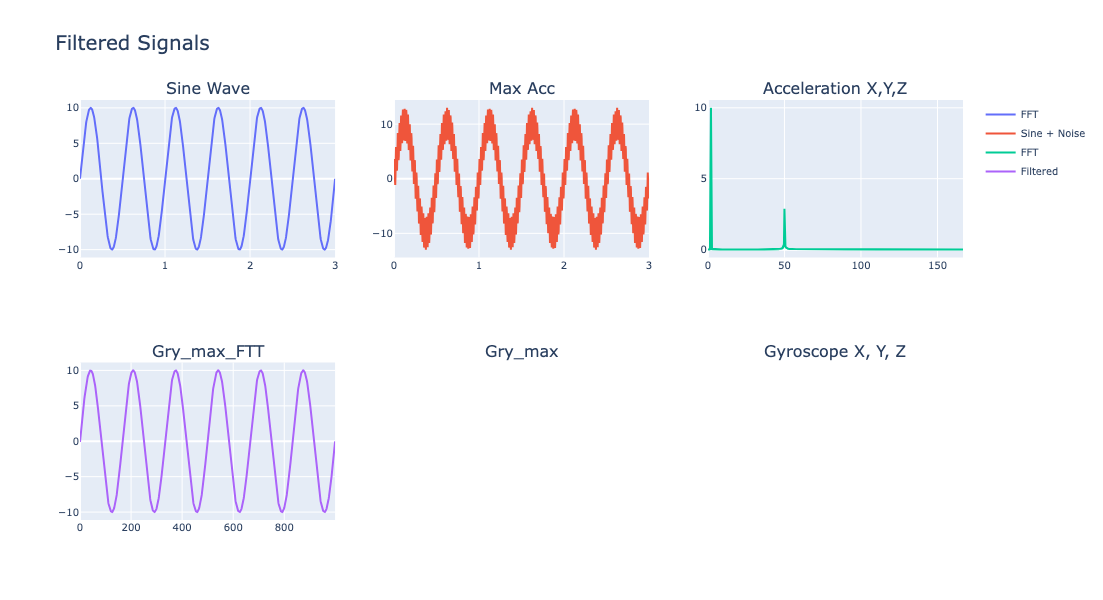

In [33]:
fig = go.Figure()
fig = make_subplots(rows=2, cols=3,
                        subplot_titles=('Sine Wave', 'Max Acc', 'Acceleration X,Y,Z',
                                        'Gry_max_FTT', 'Gry_max', 'Gyroscope X, Y, Z'))

    # Plotting Accelerometer data
fig.add_trace(go.Scatter(x=time, y=signal, mode='lines', name='FFT'), row=1, col=1)
fig.add_trace(go.Scatter(x=time, y=signal_noise, mode='lines', name='Sine + Noise'), row=1, col=2)
    # fig.add_trace(go.Scatter(x=df.index, y=df["band_pass_filtered_acc"], mode='lines', name='Max_Acc Filtered'), row=1, col=2)

fig.add_trace(go.Scatter(x=sig_noise_freq, y=sig_noise_amp, mode='lines', name='FFT '), row=1, col=3)
    # fig.add_trace(go.Scatter(x=df.index, y=df[' Accel_Y'], mode='lines', name='Raw Data'), row=1, col=3)
    # fig.add_trace(go.Scatter(x=df.index, y=df[' Accel_Z'], mode='lines', name='Raw Data'), row=1, col=3)

    # # Plotting Gyroscope data
fig.add_trace(go.Scatter(y=y  , mode='lines', name='Filtered'), row=2, col=1)
    
    # fig.add_trace(go.Scatter(x=df.index, y=df["Gry_max"], mode='lines', name='Max Gry'), row=2, col=2)
    # fig.add_trace(go.Scatter(x=df.index, y=band_pass_filtered_gry, mode='lines', name='Max Gry filtered'), row=2, col=2)

    # fig.add_trace(go.Scatter(x=df.index, y=df[' Gyro_X'], mode='lines', name='Raw Data'), row=2, col=3)
    # fig.add_trace(go.Scatter(x=df.index, y=df[' Gyro_Y'], mode='lines', name='Raw Data'), row=2, col=3)
    # fig.add_trace(go.Scatter(x=df.index, y=df[' Gyro_Z'], mode='lines', name='Raw Data'), row=2, col=3)

    # Update layout
fig.update_layout(height=600, width=1000, title_text="Filtered Signals",
                      title_font=dict(size=20), font=dict(size=10))
